C:\Users\danie\AppData\Local\Temp\ipykernel_10200\1731367236.py:20: RuntimeWarning: invalid value encountered in scalar divide
  return x-(1-p)/(np.abs(x+p)**3)*(x+p)-p*(x-1+p)/(np.abs(x-1+p)**3)


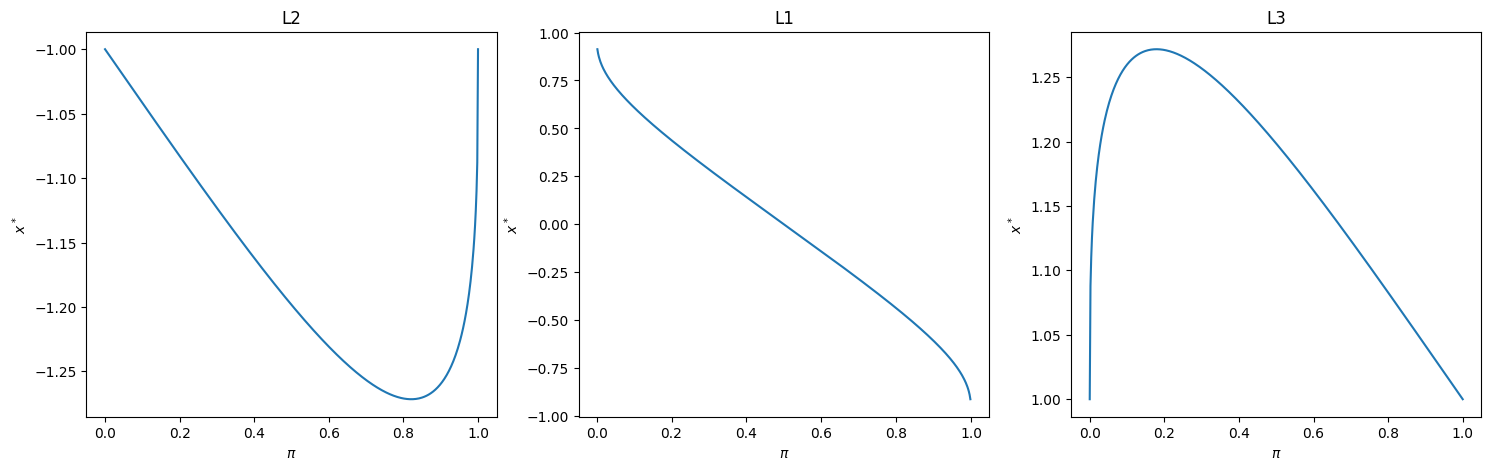

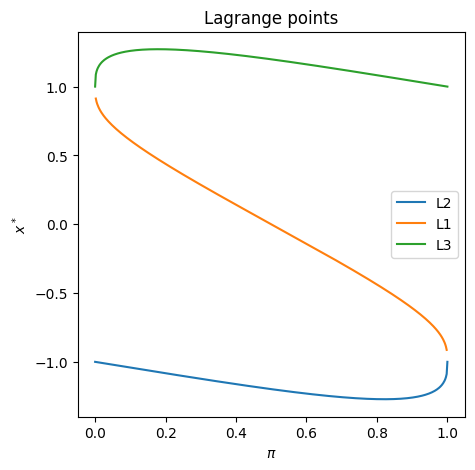

In [1]:
import numpy as np
import scipy.constants as phys
import matplotlib.pyplot as plt
from scipy.optimize import newton
pi = np.linspace(0,1,500)

sols1 = []
sols2 = []
sols3 = []
n = 100000
tol = 0.001
x1 = np.linspace(-2,-1,n)
x2 = np.linspace(-1,1,n)
x3 = np.linspace(1,2,n)

for p in pi:
    guesses = []
    
    def f(x):
        return x-(1-p)/(np.abs(x+p)**3)*(x+p)-p*(x-1+p)/(np.abs(x-1+p)**3)
    def fprim(x):
        return 1+2*(1-p)/(np.sign(x+p)*(x+p)**3)+2*p/(np.sign(x-1+p)*(x-1+p)**3)
        
    for i in range(0,n-1):
        if(np.abs(float(f(x1[i])))<tol): 
            guesses.append(x1[i])
            break
    for i in range(0,n-1):
        if(np.abs(float(f(x2[i])))<tol): 
            guesses.append(x2[i])
            break
    for i in range(0,n-1):
        if(np.abs(float(f(x3[i])))<tol): 
            guesses.append(x3[i])
            break

    sols1.append(float(newton(f, guesses[0], fprim)))
    sols2.append(float(newton(f, guesses[1], fprim)))
    sols3.append(float(newton(f, guesses[2], fprim)))

fig, ax = plt.subplots(1,3,figsize=(18,5))
ax[0].plot(pi, sols1, label = 'L2')
ax[0].set(title = 'L2', xlabel = r'$\pi$', ylabel = r'$x^*$')
ax[1].plot(pi[1:-1], sols2[1:-1], label = 'L1')
ax[1].set(title = 'L1', xlabel = r'$\pi$', ylabel = r'$x^*$')
ax[2].plot(pi, sols3, label = 'L3')
ax[2].set(title = 'L3', xlabel = r'$\pi$', ylabel = r'$x^*$')

fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(pi, sols1, label = 'L2')
ax.plot(pi[1:-1], sols2[1:-1], label = 'L1')
ax.plot(pi, sols3, label = 'L3')
ax.set(title = 'Lagrange points', xlabel = r'$\pi$', ylabel = r'$x^*$')
ax.legend()


In [1]:
import sympy as sym
x,y,z,G,m1,m2,r12,w = sym.symbols('x y z G m1 m2 r12 w')
mu1 = G*m1
mu2 = G*m2
pi = m2/(m1+m2)
r1 = sym.sqrt((x+pi*r12)**2+y**2+z**2)
r2 = sym.sqrt((x-(1-pi)*r12)**2+y**2+z**2)
U = -mu1/r1-mu2/r2-w**2/2*(x**2+y**2)
Ux = sym.diff(U,x)
Uy = sym.diff(U,y)
Uxy = sym.diff(Ux,y)
Uxx = sym.diff(Ux,x)
Uyy = sym.diff(Uy,y)

xl = (1/2-pi)*r12
yl1 = (sym.sqrt(3)/2)*r12
yl2 = -yl1
zl = 0
dicxx1 = {x:xl, y:yl1, z:zl, G:G, m1:m1, m2:m2, r12:r12, w:w}
dicxx2 = {x:xl, y:yl2, z:zl, G:G, m1:m1, m2:m2, r12:r12, w:w}
UxxL4=sym.simplify(Uxx.subs(dicxx1))
UxxL5=sym.simplify(Uxx.subs(dicxx2))
UyyL4=sym.simplify(Uyy.subs(dicxx1))
UyyL5=sym.simplify(Uyy.subs(dicxx2))
UxyL4=sym.simplify(Uxy.subs(dicxx1))
UxyL5=sym.simplify(Uxy.subs(dicxx2))

bL4 = sym.simplify(4*w**2+UxxL4+UyyL4)
cL4 = sym.simplify(UxxL4*UyyL4-UxyL4**2)
radicandoL4 = sym.simplify(bL4**2-4*cL4)
radicandoL4


bL5 = sym.simplify(4*w**2+UxxL4+UyyL4)
cL5 = sym.simplify(UxxL5*UyyL5-UxyL5**2)
radicandoL5 = sym.simplify(bL5**2-4*cL5)
radicandoL5

print(radicandoL4)
print(radicandoL5)
print(radicandoL4-radicandoL5)




1.0*G*(9.0*G*m1**2 - 9.0*G*m1*m2 + 9.0*G*m2**2 - 4.0*m1*r12**2*w**2*sqrt(r12**2*(4.0*m1**2 + 8.0*m1*m2 + 4.0*m2**2)/(m1**2 + 2*m1*m2 + m2**2)) - 4.0*m2*r12**2*w**2*sqrt(r12**2*(4.0*m1**2 + 8.0*m1*m2 + 4.0*m2**2)/(m1**2 + 2*m1*m2 + m2**2)))/r12**6
1.0*G*(9.0*G*m1**2 - 9.0*G*m1*m2 + 9.0*G*m2**2 - 4.0*m1*r12**2*w**2*sqrt(r12**2*(4.0*m1**2 + 8.0*m1*m2 + 4.0*m2**2)/(m1**2 + 2*m1*m2 + m2**2)) - 4.0*m2*r12**2*w**2*sqrt(r12**2*(4.0*m1**2 + 8.0*m1*m2 + 4.0*m2**2)/(m1**2 + 2*m1*m2 + m2**2)))/r12**6
0


In [ ]:
import sympy as sp
from IPython.display import Latex, display
r1,r2,r3,phi1,phi2,phi3,m1,m2,m3,G, pr1,pr2,pr3,pphi1,pphi2,pphi3 = sp.symbols('r1 r2 r3 phi1 phi2 phi3 m1 m2 m3 G pr1 pr2 pr3 pphi1 pphi2 pphi3')
H = 1/2*(pr1**2/m1+pphi1**2/(m1*r1**2)+pr2**2/m2+pphi2**2/(m2*r2**2)+pr3**2/m3+pphi3**2/(m3*r3**2))-(G*m1*m2/(sp.sqrt(r1**2+r2**2-2*r1*r2*sp.cos(phi1-phi2)))+
                                                                                                     G*m1*m3/(sp.sqrt(r1**2+r3**2-2*r1*r3*sp.cos(phi1-phi3)))+
                                                                                                     G*m2*m3/(sp.sqrt(r2**2+r3**2-2*r2*r3*sp.cos(phi2-phi3))))
eq1 = sp.latex(sp.simplify(-sp.diff(H,r1)))
eq2 = sp.latex(sp.simplify(-sp.diff(H,r2)))
eq3 = sp.latex(sp.simplify(-sp.diff(H,r3)))
eq4 = sp.latex(sp.simplify(-sp.diff(H,phi1)))
eq5 = sp.latex(sp.simplify(-sp.diff(H,phi2)))
eq6 = sp.latex(sp.simplify(-sp.diff(H,phi3)))
#display(Latex(eq6))

eq1: $\dot{p}_{r1}=\frac{G m_{1} m_{2} r_{1}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} + \frac{G m_{1} m_{2} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{1} m_{3} r_{1}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{G m_{1} m_{3} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{1.0 pphi_{1}^{2}}{m_{1} r_{1}^{3}}$

eq2: $\dot{p}_{r2}=\frac{G m_{1} m_{2} r_{1} \cos{\left(\phi_{1} - \phi_{2} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{1} m_{2} r_{2}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{2} m_{3} r_{2}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{G m_{2} m_{3} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{1.0 pphi_{2}^{2}}{m_{2} r_{2}^{3}}$

eq3: $\dot{p}_{r3}=\frac{G m_{1} m_{3} r_{1} \cos{\left(\phi_{1} - \phi_{3} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{1} m_{3} r_{3}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{G m_{2} m_{3} r_{2} \cos{\left(\phi_{2} - \phi_{3} \right)}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{2} m_{3} r_{3}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{1.0 pphi_{3}^{2}}{m_{3} r_{3}^{3}}$

eq4: $\dot{p}_{\varphi1}=\frac{G m_{1} m_{2} r_{1} r_{2} \sin{\left(\phi_{1} - \phi_{2} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{1} m_{3} r_{1} r_{3} \sin{\left(\phi_{1} - \phi_{3} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}}$

eq5: $\dot{p}_{\varphi2}=\frac{G m_{1} m_{2} r_{1} r_{2} \sin{\left(\phi_{1} - \phi_{2} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{2} \cos{\left(\phi_{1} - \phi_{2} \right)} + r_{2}^{2}\right)^{\frac{3}{2}}} - \frac{G m_{2} m_{3} r_{2} r_{3} \sin{\left(\phi_{2} - \phi_{3} \right)}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}}$

eq6: $\dot{p}_{\varphi3}=\frac{G m_{1} m_{3} r_{1} r_{3} \sin{\left(\phi_{1} - \phi_{3} \right)}}{\left(r_{1}^{2} - 2 r_{1} r_{3} \cos{\left(\phi_{1} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}} + \frac{G m_{2} m_{3} r_{2} r_{3} \sin{\left(\phi_{2} - \phi_{3} \right)}}{\left(r_{2}^{2} - 2 r_{2} r_{3} \cos{\left(\phi_{2} - \phi_{3} \right)} + r_{3}^{2}\right)^{\frac{3}{2}}}$

Exponente de Lyapunov:  -7.770064785674198e-07 $\pm$ 9.45872668654595e-10 
 R2:  0.9997066717743193


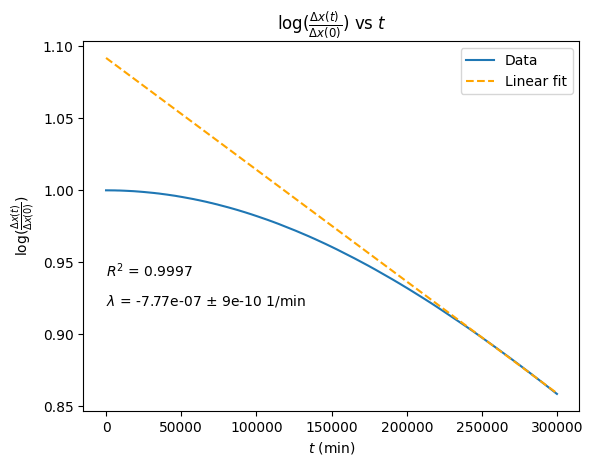

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 1000
inddown = 800

h = 5*60
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt)/np.log(Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$ (min)')
ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()


In [12]:
import numpy as np
import scipy.constants as phys
import matplotlib.pyplot as plt
from scipy.optimize import newton

MT = 5.97e24
MSun = 1.989e30
pi = np.array([MT/(MT+MSun)])

sols1 = []
sols2 = []
sols3 = []
n = 100000
tol = 0.001
x1 = np.linspace(-2,-1,n)
x2 = np.linspace(-1,1,n)
x3 = np.linspace(1,2,n)

for p in pi:
    guesses = []
    
    def f(x):
        return x-(1-p)/(np.abs(x+p)**3)*(x+p)-p*(x-1+p)/(np.abs(x-1+p)**3)
    def fprim(x):
        return 1+2*(1-p)/(np.sign(x+p)*(x+p)**3)+2*p/(np.sign(x-1+p)*(x-1+p)**3)
        
    for i in range(0,n-1):
        if(np.abs(float(f(x1[i])))<tol): 
            guesses.append(x1[i])
            break
    for i in range(0,n-1):
        if(np.abs(float(f(x2[i])))<tol): 
            guesses.append(x2[i])
            break
    for i in range(0,n-1):
        if(np.abs(float(f(x3[i])))<tol): 
            guesses.append(x3[i])
            break

    sols1.append(float(newton(f, guesses[0], fprim)))
    sols2.append(float(newton(f, guesses[1], fprim)))
    sols3.append(float(newton(f, guesses[2], fprim)))

ele1 = sols3[0]
print(ele1)
print(100*(np.abs(ele1-1-0.01))/0.01)

1.0100319035631007
0.3190356310068566


C:\Users\danie\AppData\Local\Temp\ipykernel_3376\3796975570.py:15: RuntimeWarning: divide by zero encountered in log
  logDeltaxt = np.log(Deltaxt/Deltax0)


Exponente de Lyapunov:  0.0012069456684270304 $\pm$ 1.8965317637625985e-05 
 R2:  0.019848279068741412


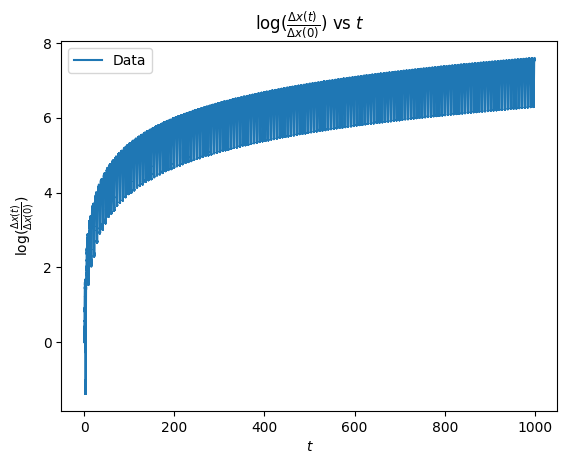

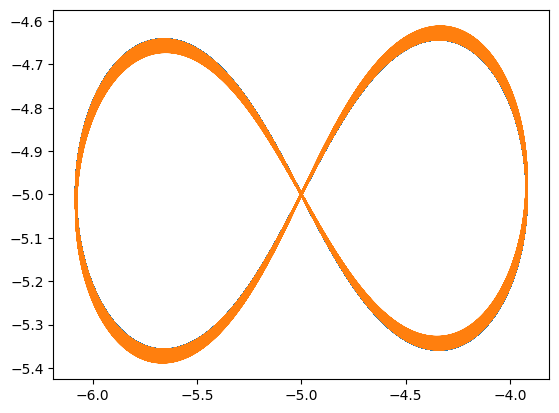

In [83]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 1000000
inddown = 800000

h = 0.001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_3376\1015364001.py:15: RuntimeWarning: divide by zero encountered in log
  logDeltaxt = np.log(Deltaxt/Deltax0)


Exponente de Lyapunov:  0.0011002532680884913 $\pm$ 1.418299617347249e-05 
 R2:  0.029211139781090193


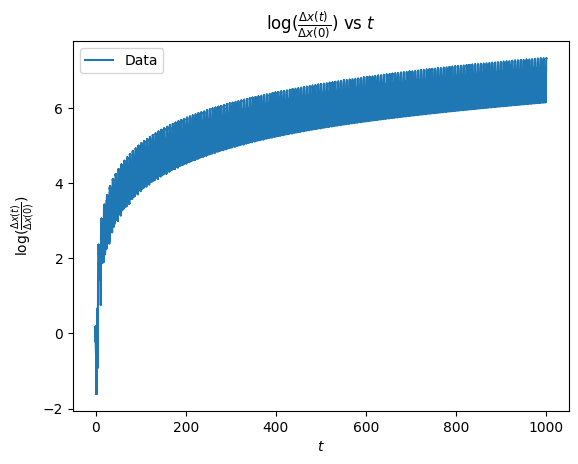

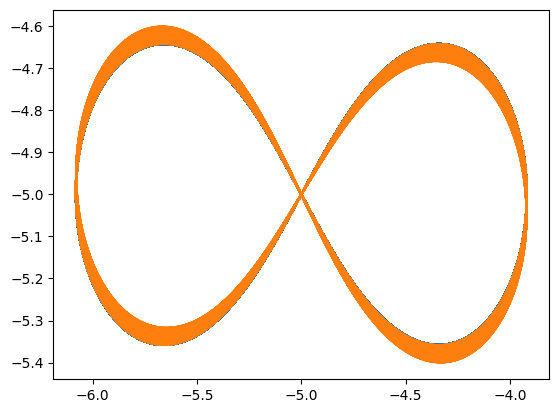

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 1000000
inddown = 800000

h = 0.001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()
#pert en y[1]

Exponente de Lyapunov:  0.055054821421593014 $\pm$ 3.11263122139709e-05 
 R2:  0.49435065742413337


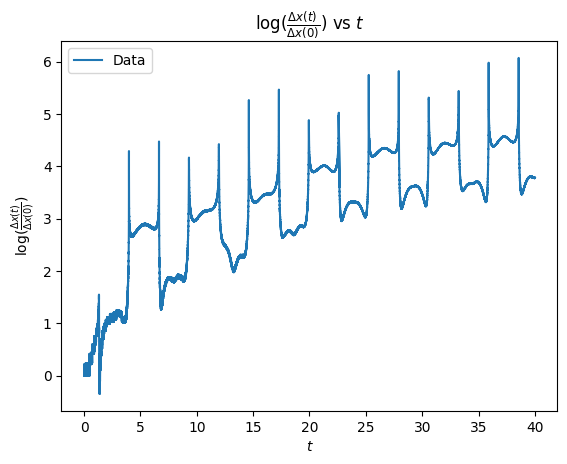

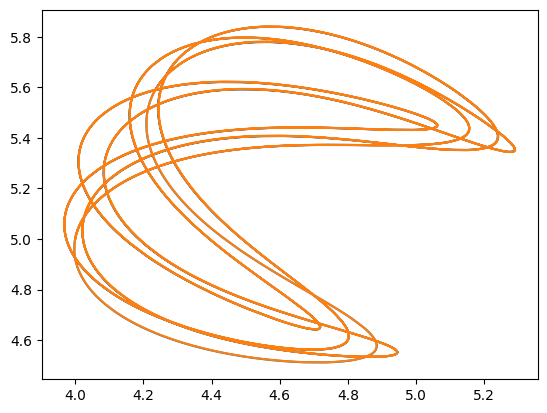

In [91]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 4000000
inddown = 800000

h = 0.00001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

C:\Users\danie\AppData\Local\Temp\ipykernel_3376\142206278.py:15: RuntimeWarning: divide by zero encountered in log
  logDeltaxt = np.log(Deltaxt/Deltax0)


Exponente de Lyapunov:  0.017842310714282883 $\pm$ 9.917183043451102e-05 
 R2:  0.015926614312293082


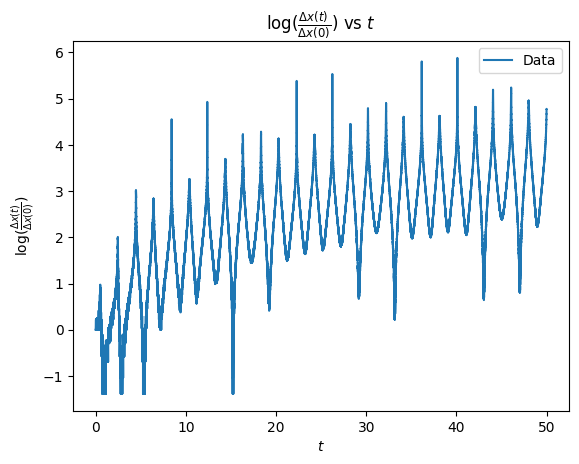

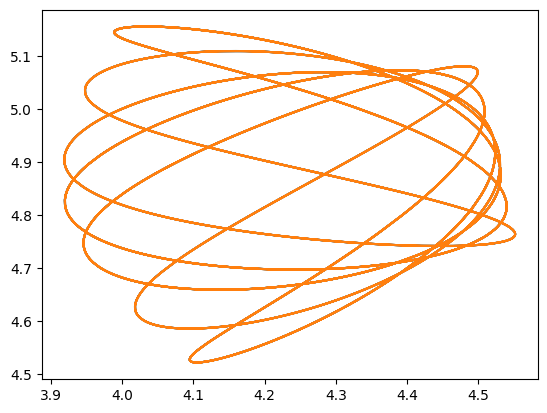

In [94]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 5000000
inddown = 3000000

h = 0.00001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

Exponente de Lyapunov:  0.025167942135999266 $\pm$ 3.757394948467418e-06 
 R2:  0.957325591782318


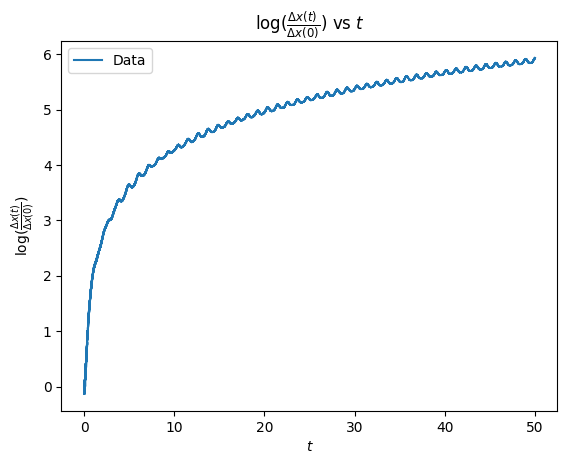

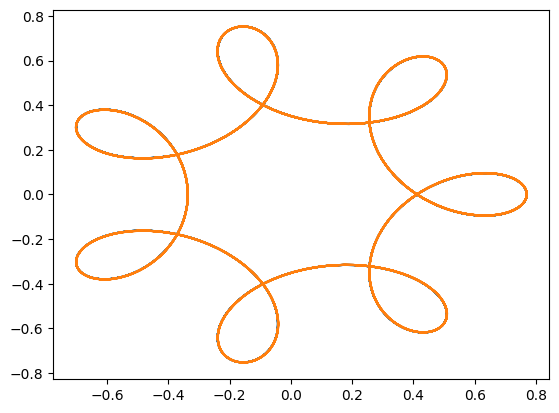

In [97]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 5000000
inddown = 3000000

h = 0.00001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

Exponente de Lyapunov:  0.002530036949444615 $\pm$ 3.80605643543641e-07 
 R2:  0.956698649214997


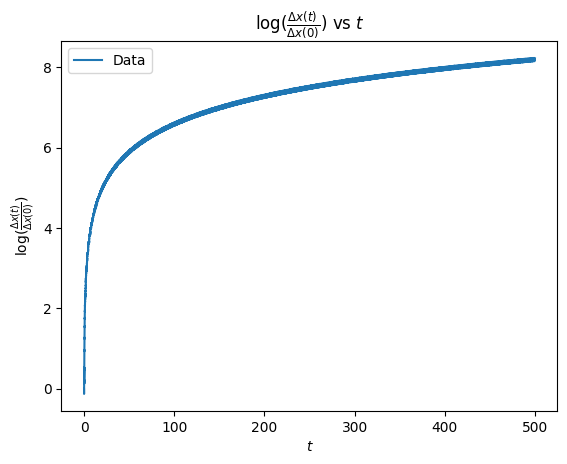

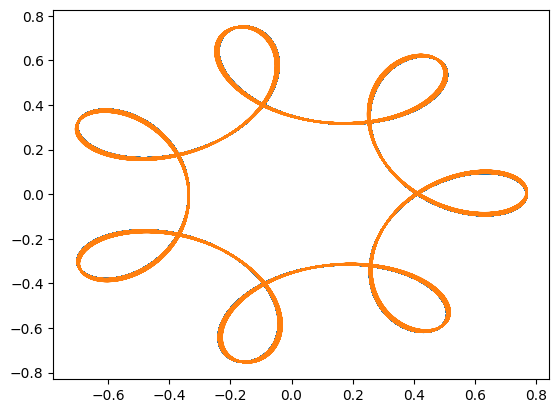

In [99]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 5000000
inddown = 3000000

h = 0.0001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

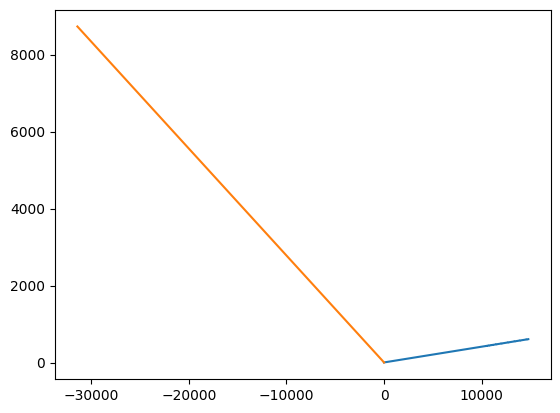

C:\Users\danie\AppData\Local\Temp\ipykernel_20720\143873623.py:19: RuntimeWarning: divide by zero encountered in log
  logDeltaxt = np.log(Deltaxt/Deltax0)


Exponente de Lyapunov:  0.0022316569373679877 $\pm$ 6.436415727341586e-08 
 R2:  0.9991688654510661


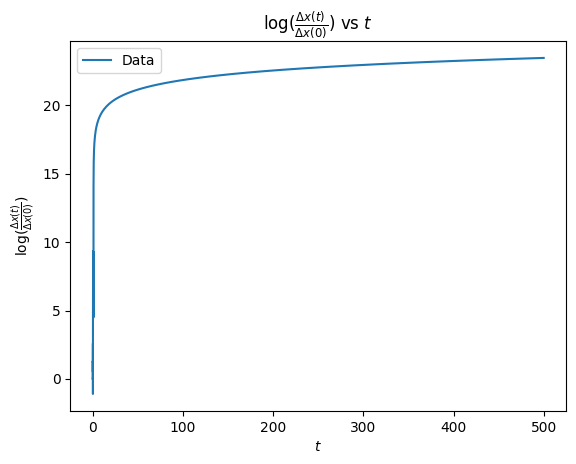

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1random.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pertrandom.txt"))
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()
indup = 5000000
inddown = 4000000

h = 0.0001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,1.2,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)}')
ax.legend()

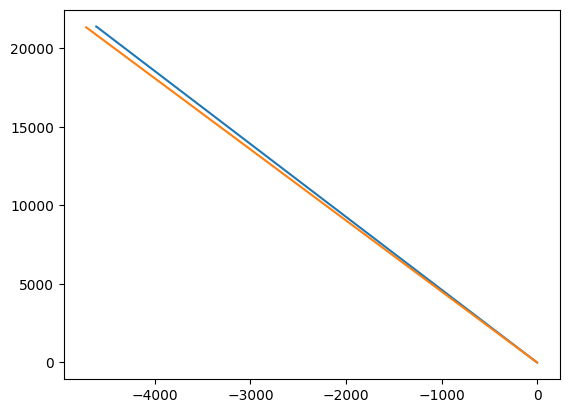

Exponente de Lyapunov:  0.00010533813100835374 $\pm$ 4.860190502072995e-09 
 R2:  0.9997871693191362


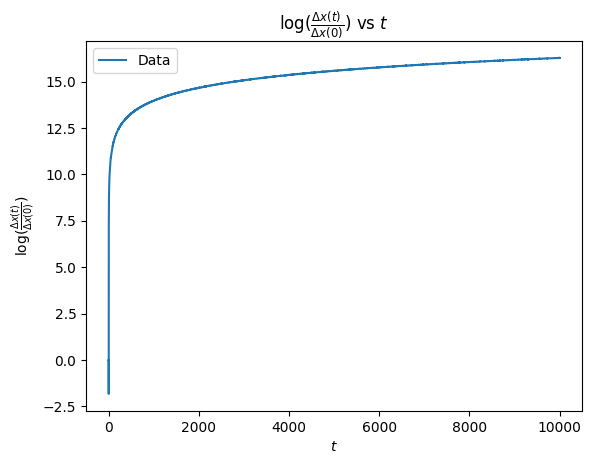

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa2random.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa2pertrandom.txt"))
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()
indup = 1000000
inddown = 900000

h = 0.01
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,1.2,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)}')
ax.legend()

Exponente de Lyapunov:  0.00022958071897460908 $\pm$ 3.989380766308907e-08 
 R2:  0.9430486757937212


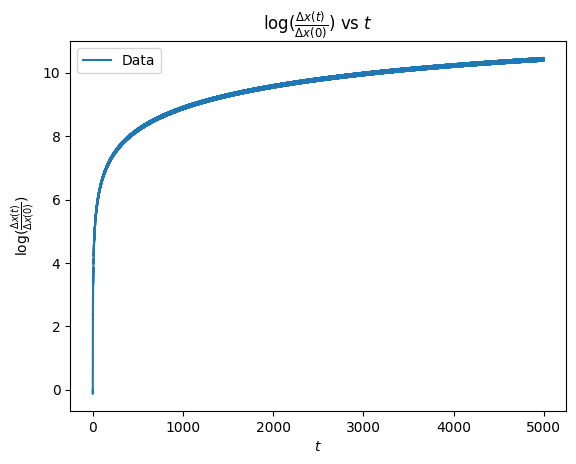

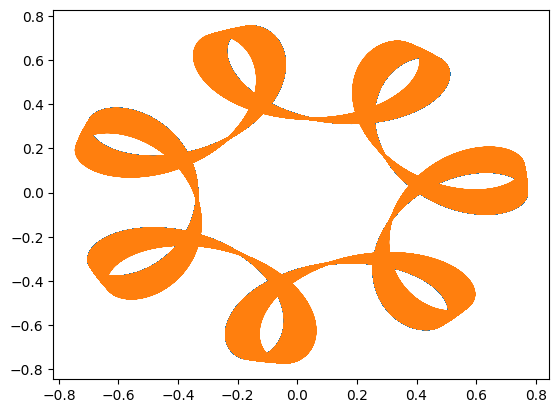

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa1.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa1pert.txt"))
indup = 5000000
inddown = 3000000

h = 0.001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()

Exponente de Lyapunov:  0.00025311701806296494 $\pm$ 1.178102644620137e-08 
 R2:  0.9956860456562935


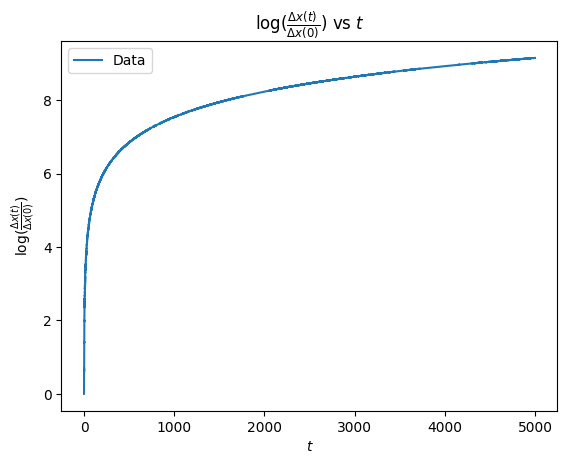

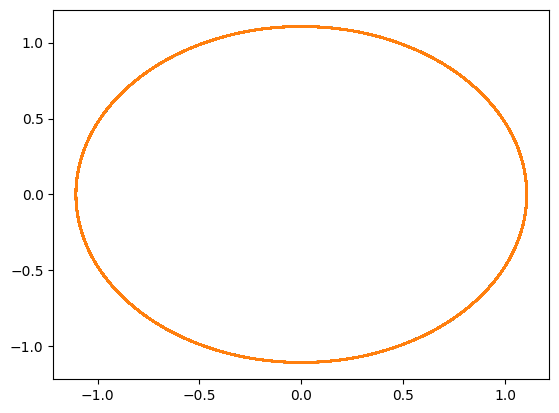

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x,y = np.transpose(np.loadtxt("Masa2.txt"))
xpert,ypert = np.transpose(np.loadtxt("Masa2pert.txt"))
indup = 5000000
inddown = 3000000

h = 0.001
Deltaxt = np.sqrt((x[0:indup]-xpert[0:indup])**2+(y[0:indup]-ypert[0:indup])**2)
Deltax0 = np.sqrt((x[0]-xpert[0])**2+(y[0]-ypert[0])**2)

t = np.arange(0,indup)*h

logDeltaxt = np.log(Deltaxt/Deltax0)

from scipy.optimize import curve_fit
def f(x,a,b):
    return a*x+b
popt, pcov = curve_fit(f,t[inddown:],logDeltaxt[inddown:])
R2 = np.corrcoef(t[inddown:],logDeltaxt[inddown:])[0,1]**2
print("Exponente de Lyapunov: ", popt[0], r'$\pm$', np.sqrt(pcov[0,0]), '\n', 'R2: ', R2)
y_pred = popt[0]*t+popt[1]


fig, ax = plt.subplots()
ax.plot(t, logDeltaxt, label='Data')
#ax.plot(t, y_pred, linestyle='--', color = 'orange', label= 'Linear fit')
ax.set(title = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$ vs $t$', ylabel = r'$\mathrm{log}(\frac{\Delta x(t)}{\Delta x(0)})$', xlabel = '$t$')
#ax.text(1,0.94,fr'$R^2$ = {np.round(R2,4)}')
#ax.text(1,0.92,fr'$\lambda$ = {np.round(popt[0],10)} $\pm$ {np.round(np.sqrt(pcov[0,0]),10)} 1/min')
ax.legend()
plt.figure()
plt.plot(x,y)
plt.plot(xpert,ypert)
plt.show()